### Analyse exploratoire de données (EDA): Dans cette partie, nous visualiserons la distribution, la corrélation et la relation entre les caractéristiques et notre variable variable cible.

In [20]:
# Importating necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
import missingno as msno
warnings.filterwarnings('ignore')

In [2]:
# Loading dataset
data = pd.read_csv("..\\data\\raw\\train.csv")
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# Checking the shape of the dataset
print("Shape of the dataset:", data.shape)

Shape of the dataset: (1460, 81)


In [4]:
# General information about the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
# Let's delete the 'Id' column as it is not useful for our analysis
data.drop("Id", axis=1, inplace=True)
data.head(3)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


In [6]:
# Statistical overview of the dataset
data.describe().T

,count,mean,std,min,25%,50%,75%,max
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0
BsmtFinSF2,1460.0,46.549315,161.319273,0.0,0.00,0.0,0.00,1474.0


In [7]:
# Checking for missing values
def missing_values(data):
    missing = data.isnull().sum()
    missing = missing[missing > 0]
    missing.sort_values(inplace=True)
    return missing

print("Missing values in the dataset:\n", missing_values(data))

Missing values in the dataset:
 Electrical         1
MasVnrArea         8
BsmtCond          37
BsmtFinType1      37
BsmtQual          37
BsmtExposure      38
BsmtFinType2      38
GarageType        81
GarageQual        81
GarageFinish      81
GarageCond        81
GarageYrBlt       81
LotFrontage      259
FireplaceQu      690
MasVnrType       872
Fence           1179
Alley           1369
MiscFeature     1406
PoolQC          1453
dtype: int64


In [8]:
# Checking deduplication of the dataset 
print("Number of duplicate rows in the dataset:", data.duplicated().sum())

Number of duplicate rows in the dataset: 0


In [9]:
# Identifying categorical features
categorical_features = data.select_dtypes(include="object").columns
print(categorical_features)
print("Nombre de colonnes catégorielles:", len(categorical_features))

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')
Nombre de colonnes catégorielles: 43


<Axes: xlabel='SalePrice', ylabel='Count'>

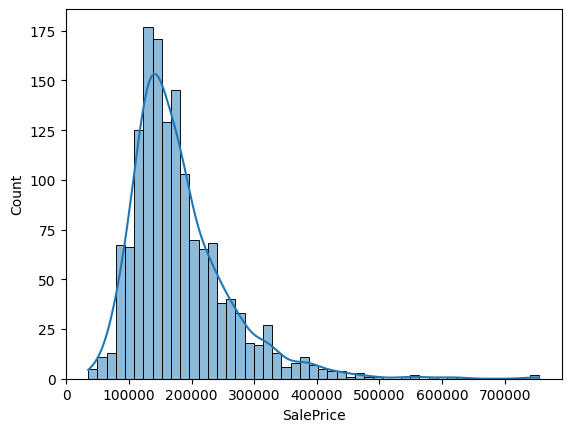

In [10]:
# Distribution of SalePrice
sns.histplot(data["SalePrice"], kde=True)

array([[<Axes: title={'center': 'MSSubClass'}>,
        <Axes: title={'center': 'LotFrontage'}>,
        <Axes: title={'center': 'LotArea'}>,
        <Axes: title={'center': 'OverallQual'}>,
        <Axes: title={'center': 'OverallCond'}>,
        <Axes: title={'center': 'YearBuilt'}>],
       [<Axes: title={'center': 'YearRemodAdd'}>,
        <Axes: title={'center': 'MasVnrArea'}>,
        <Axes: title={'center': 'BsmtFinSF1'}>,
        <Axes: title={'center': 'BsmtFinSF2'}>,
        <Axes: title={'center': 'BsmtUnfSF'}>,
        <Axes: title={'center': 'TotalBsmtSF'}>],
       [<Axes: title={'center': '1stFlrSF'}>,
        <Axes: title={'center': '2ndFlrSF'}>,
        <Axes: title={'center': 'LowQualFinSF'}>,
        <Axes: title={'center': 'GrLivArea'}>,
        <Axes: title={'center': 'BsmtFullBath'}>,
        <Axes: title={'center': 'BsmtHalfBath'}>],
       [<Axes: title={'center': 'FullBath'}>,
        <Axes: title={'center': 'HalfBath'}>,
        <Axes: title={'center': 'Bedroo

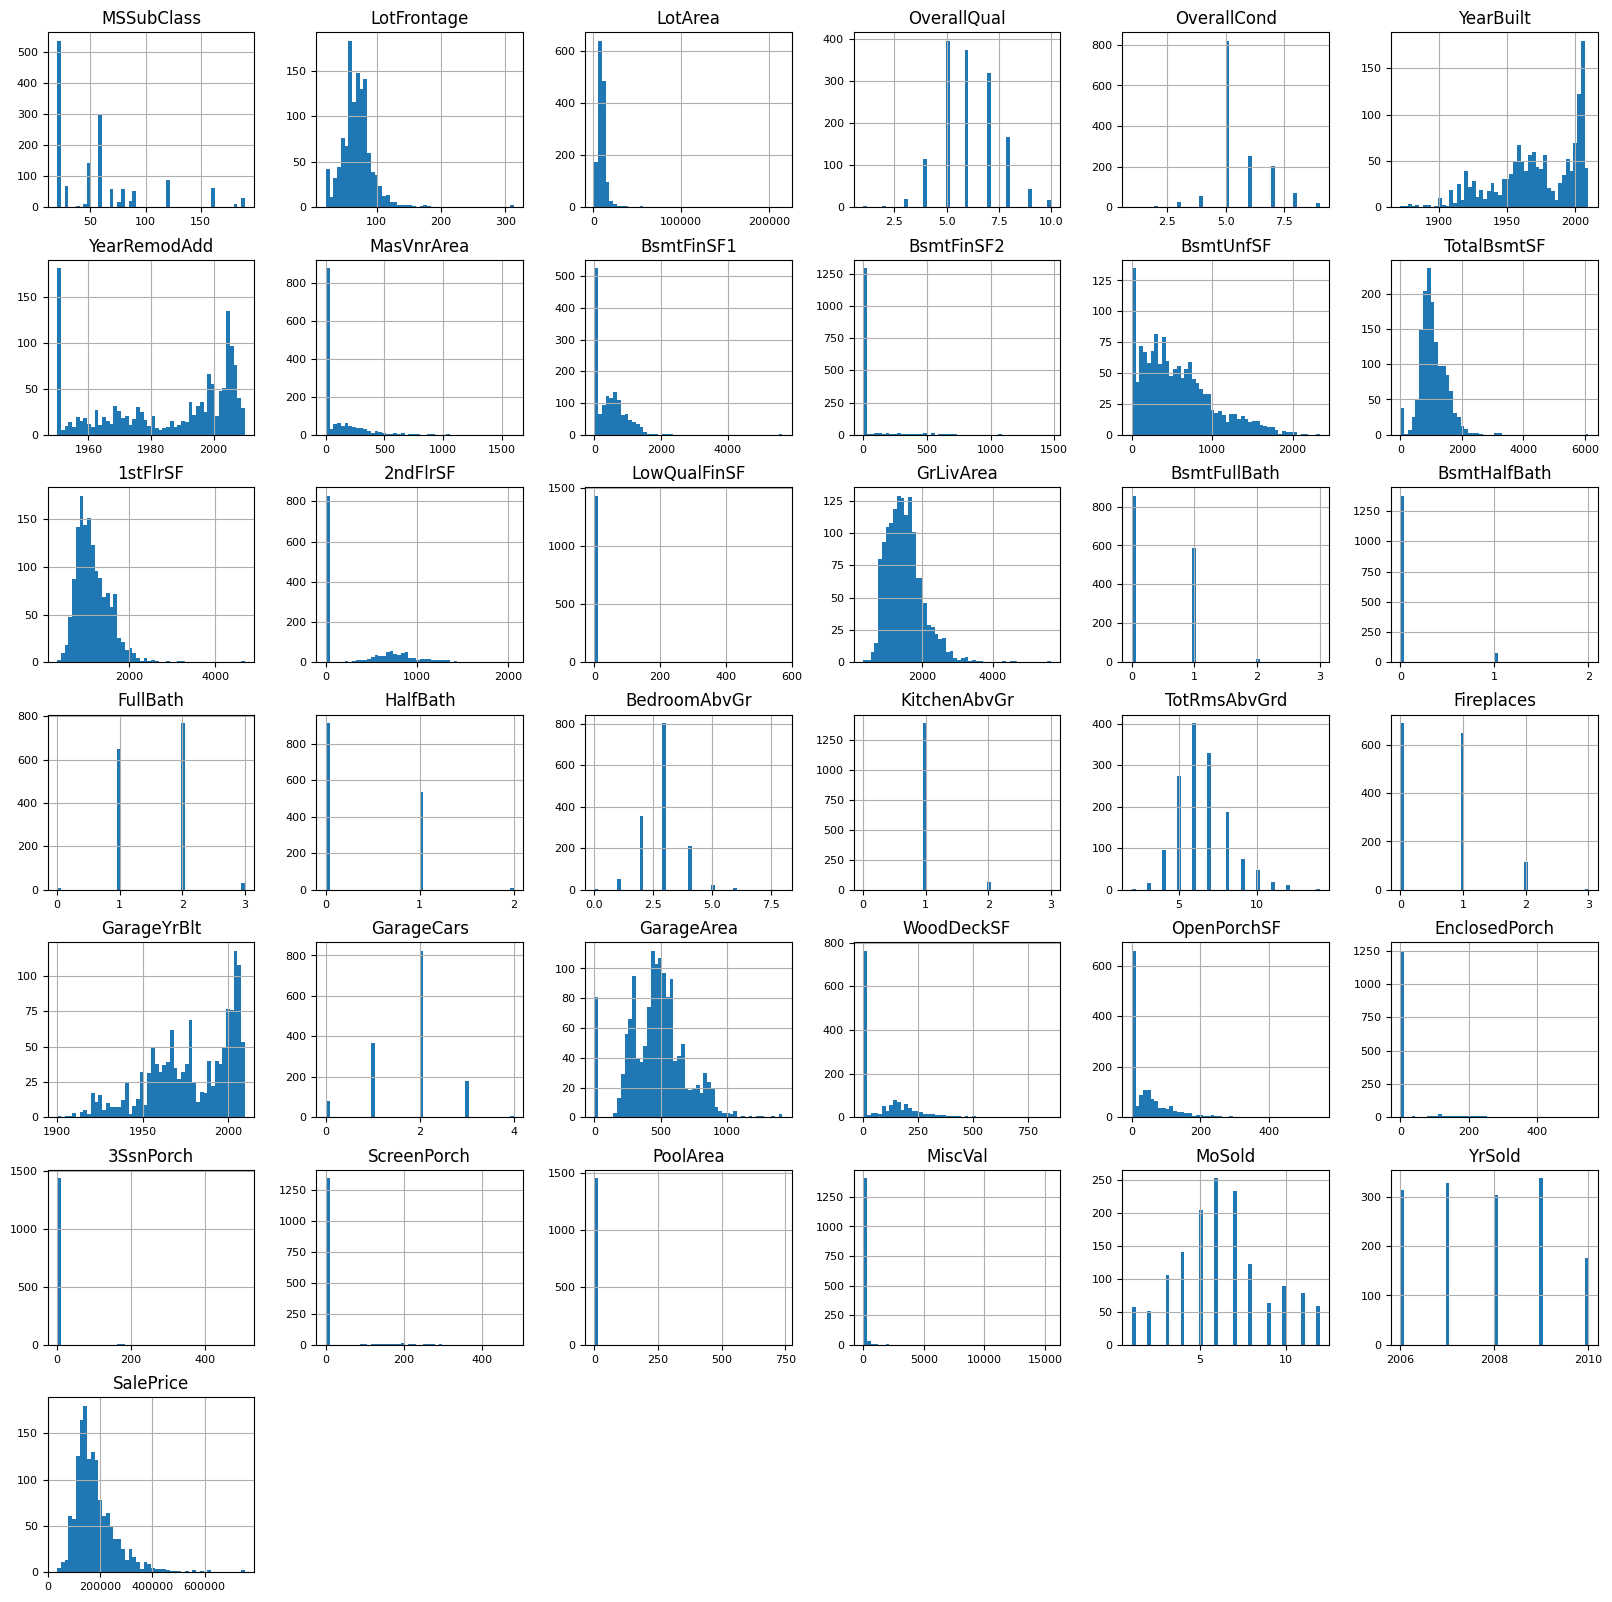

In [11]:
# Histogram for all numeric features distribution
data.hist(figsize=(20,20), bins=50, xlabelsize=8, ylabelsize=8)

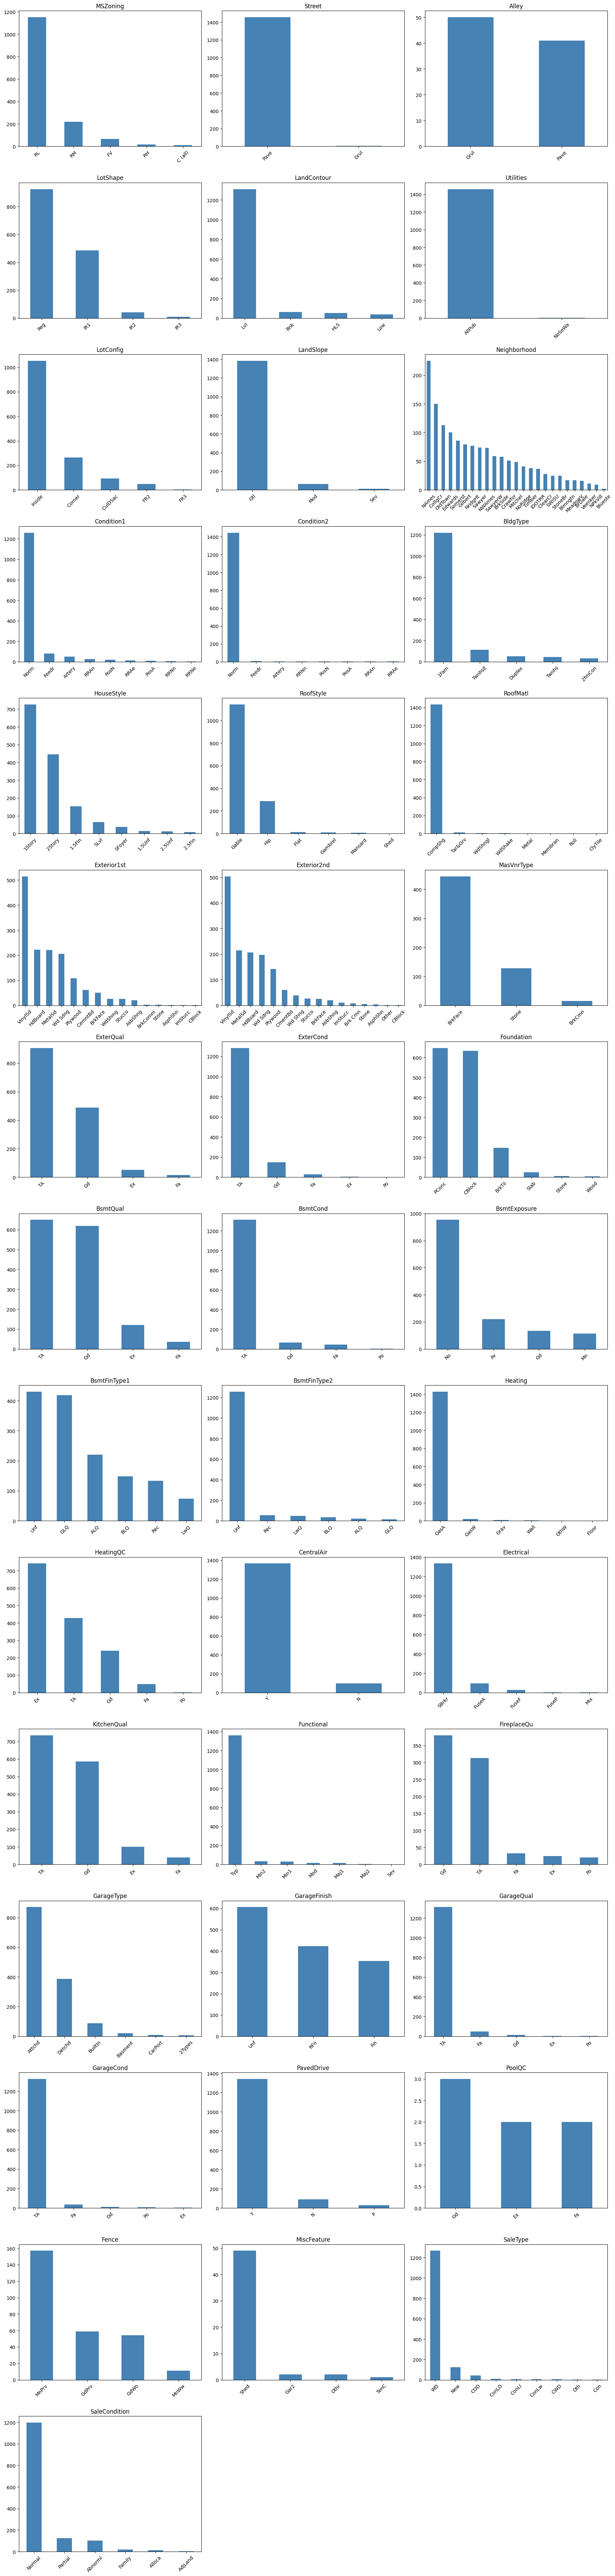

In [ ]:
# Countplots for categorical features
categorical_features = data.select_dtypes(include="object").columns
n_cols = 3
n_rows = (len(categorical_features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()
for i, col in enumerate(categorical_features):
    data[col].value_counts().plot(kind='bar', ax=axes[i], color='steelblue')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

<Axes: xlabel='SalePrice'>

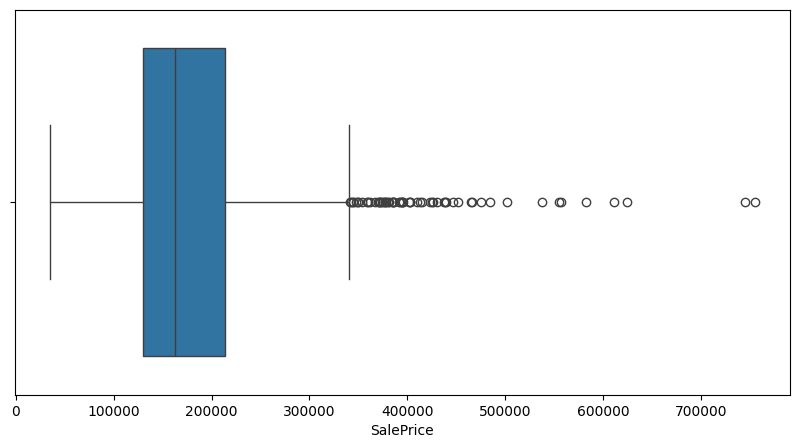

In [12]:
# Boxplot for SalePrice
plt.figure(figsize=(10,5))
sns.boxplot(x=data["SalePrice"])

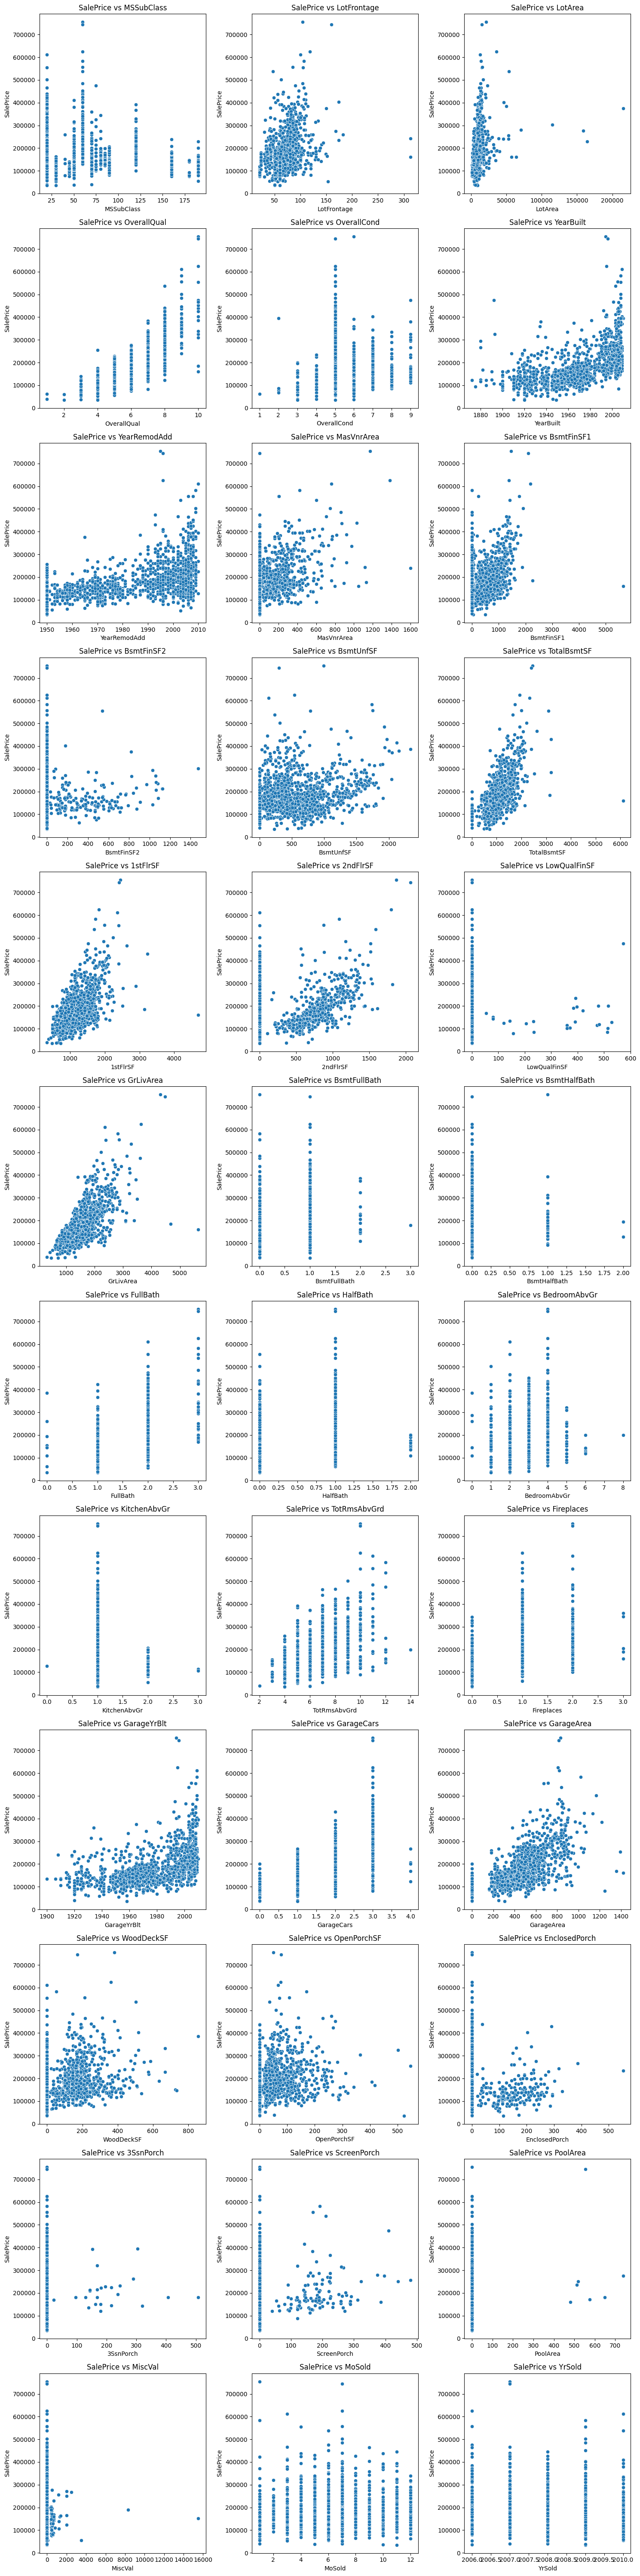

In [13]:
# Scatter plots of SalePrice against numeric features
numerical_features = data.select_dtypes(include=['int64','float64']).columns
numerical_features = numerical_features.drop("SalePrice")
n_cols = 3  
n_rows = (len(numerical_features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()
for i, col in enumerate(numerical_features):
    sns.scatterplot(x=data[col], y=data["SalePrice"], ax=axes[i])
    axes[i].set_title(f"SalePrice vs {col}")
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

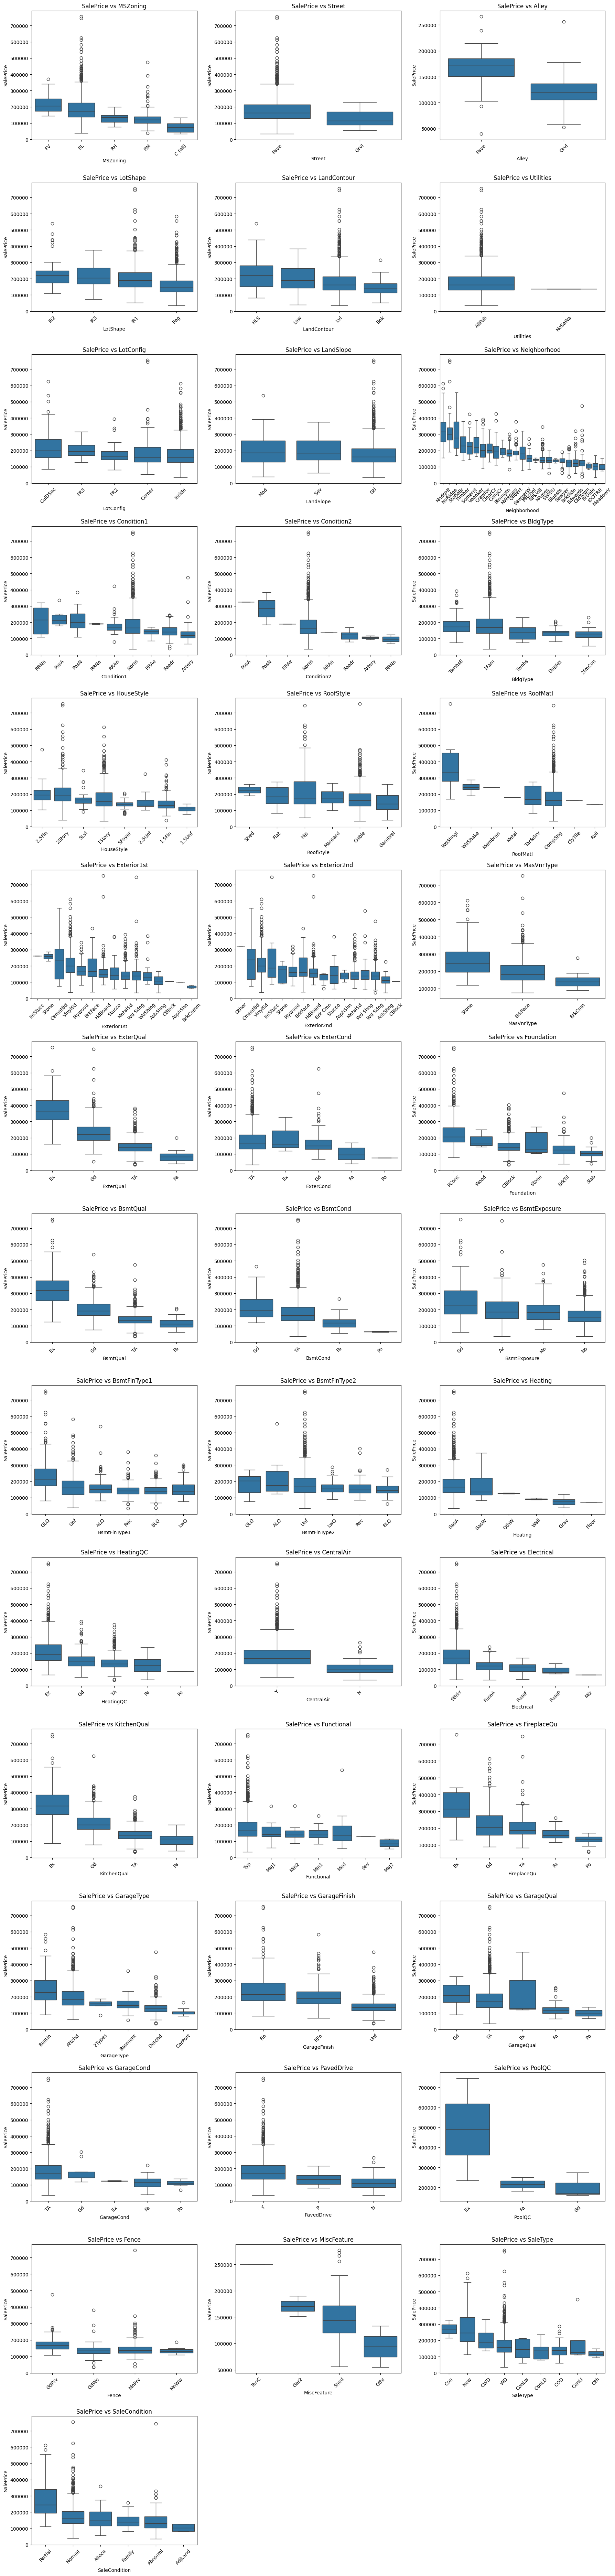

In [18]:
# Boxplots: SalePrice by categorical feature
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()
for i, col in enumerate(categorical_features):
    order = data.groupby(col)["SalePrice"].median().sort_values(ascending=False).index
    sns.boxplot(x=data[col], y=data["SalePrice"], order=order, ax=axes[i])
    axes[i].set_title(f"SalePrice vs {col}")
    axes[i].tick_params(axis='x', rotation=45)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

In [14]:
# Correlation of numeric features
data.corr(numeric_only=True)

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
MSSubClass,1.000000,-0.386347,-0.139781,0.032628,-0.059316,0.027850,0.040581,0.022936,-0.069836,-0.065649,...,-0.012579,-0.006100,-0.012037,-0.043825,-0.026030,0.008283,-0.007683,-0.013585,-0.021407,-0.084284
LotFrontage,-0.386347,1.000000,0.426095,0.251646,-0.059213,0.123349,0.088866,0.193458,0.233633,0.049900,...,0.088521,0.151972,0.010700,0.070029,0.041383,0.206167,0.003368,0.011200,0.007450,0.351799
LotArea,-0.139781,0.426095,1.000000,0.105806,-0.005636,0.014228,0.013788,0.104160,0.214103,0.111170,...,0.171698,0.084774,-0.018340,0.020423,0.043160,0.077672,0.038068,0.001205,-0.014261,0.263843
OverallQual,0.032628,0.251646,0.105806,1.000000,-0.091932,0.572323,0.550684,0.411876,0.239666,-0.059119,...,0.238923,0.308819,-0.113937,0.030371,0.064886,0.065166,-0.031406,0.070815,-0.027347,0.790982
OverallCond,-0.059316,-0.059213,-0.005636,-0.091932,1.000000,-0.375983,0.073741,-0.128101,-0.046231,0.040229,...,-0.003334,-0.032589,0.070356,0.025504,0.054811,-0.001985,0.068777,-0.003511,0.043950,-0.077856
YearBuilt,0.027850,0.123349,0.014228,0.572323,-0.375983,1.000000,0.592855,0.315707,0.249503,-0.049107,...,0.224880,0.188686,-0.387268,0.031355,-0.050364,0.004950,-0.034383,0.012398,-0.013618,0.522897
YearRemodAdd,0.040581,0.088866,0.013788,0.550684,0.073741,0.592855,1.000000,0.179618,0.128451,-0.067759,...,0.205726,0.226298,-0.193919,0.045286,-0.038740,0.005829,-0.010286,0.021490,0.035743,0.507101
MasVnrArea,0.022936,0.193458,0.104160,0.411876,-0.128101,0.315707,0.179618,1.000000,0.264736,-0.072319,...,0.159718,0.125703,-0.110204,0.018796,0.061466,0.011723,-0.029815,-0.005965,-0.008201,0.477493
BsmtFinSF1,-0.069836,0.233633,0.214103,0.239666,-0.046231,0.249503,0.128451,0.264736,1.000000,-0.050117,...,0.204306,0.111761,-0.102303,0.026451,0.062021,0.140491,0.003571,-0.015727,0.014359,0.386420
BsmtFinSF2,-0.065649,0.049900,0.111170,-0.059119,0.040229,-0.049107,-0.067759,-0.072319,-0.050117,1.000000,...,0.067898,0.003093,0.036543,-0.029993,0.088871,0.041709,0.004940,-0.015211,0.031706,-0.011378


<Axes: >

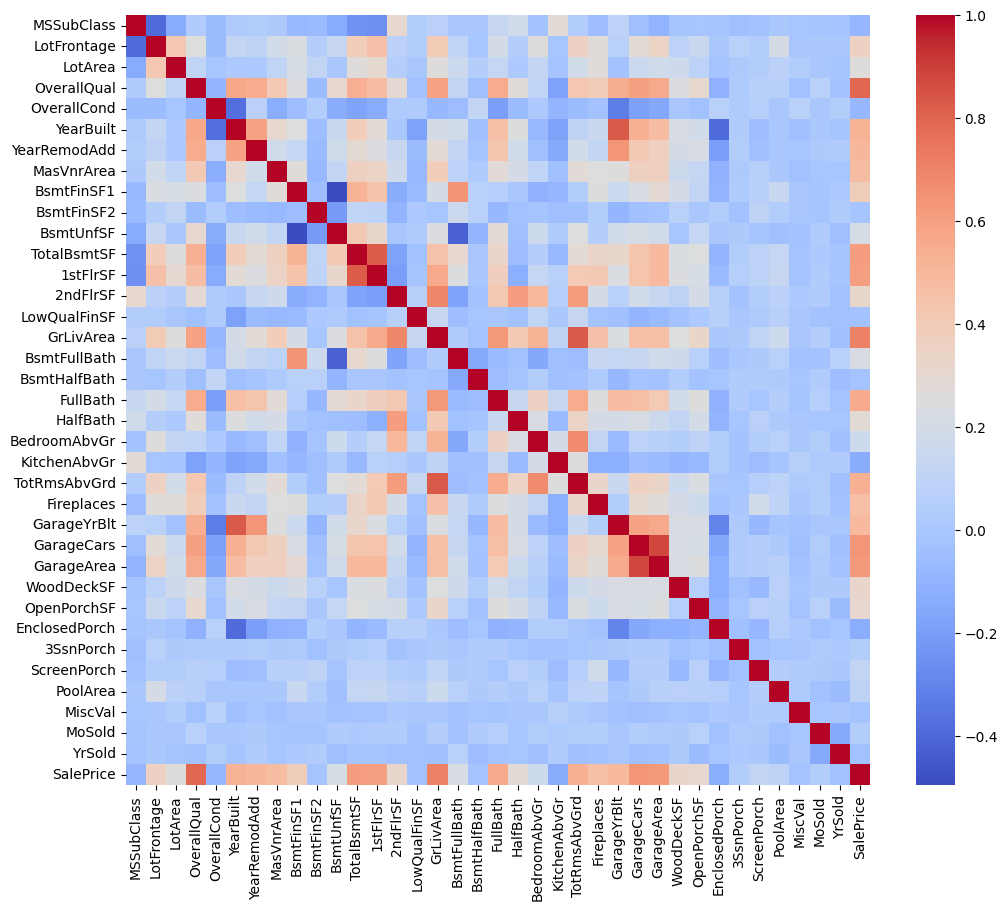

In [15]:
# Correlation of numeric features heatmap
figsize=(12,10)
plt.figure(figsize=figsize)
corr = data.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm")

In [16]:
# Correlation of numeric features with SalePrice
data.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64

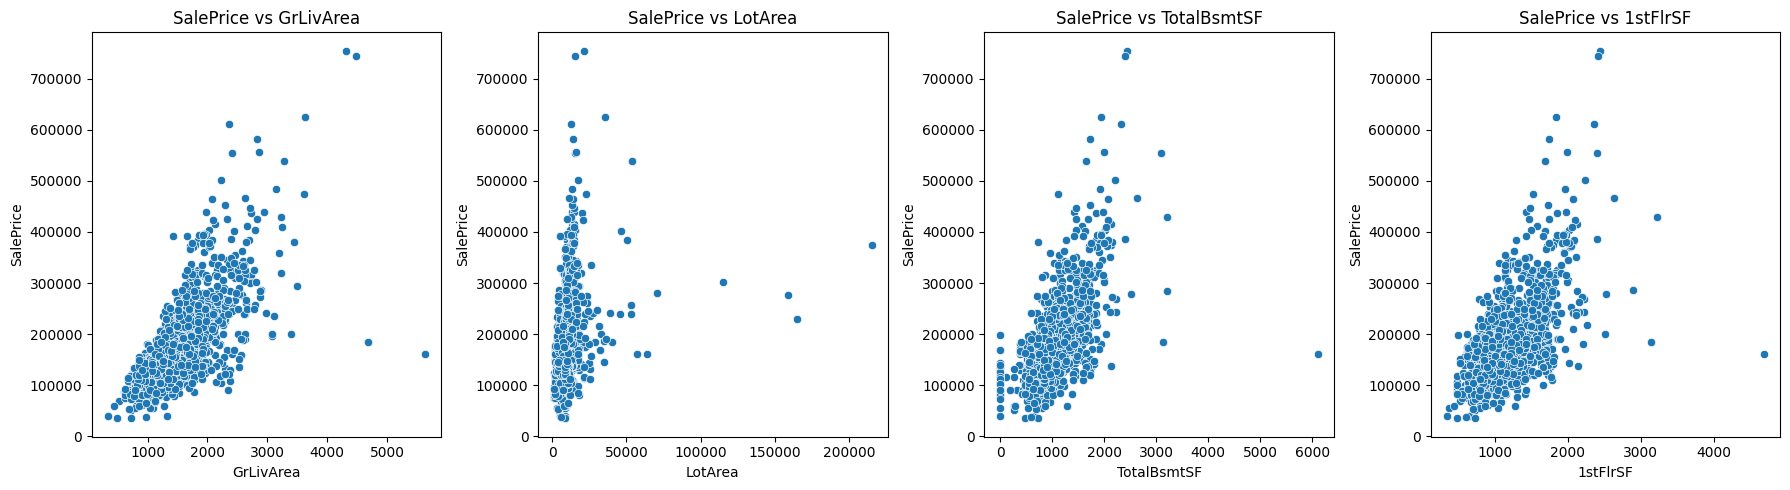

GrLivArea: 31 outliers détectés
LotArea: 69 outliers détectés
TotalBsmtSF: 61 outliers détectés
1stFlrSF: 20 outliers détectés


In [23]:
# Outlier detection on top correlated features
top_features = ["GrLivArea", "LotArea", "TotalBsmtSF", "1stFlrSF"]

fig, axes = plt.subplots(1, len(top_features), figsize=(18, 5))

for i, col in enumerate(top_features):
    sns.scatterplot(x=data[col], y=data["SalePrice"], ax=axes[i])
    axes[i].set_title(f"SalePrice vs {col}")

plt.tight_layout()
plt.show()

# Flag outliers using IQR
for col in top_features:
    Q1, Q3 = data[col].quantile(0.25), data[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = data[(data[col] < Q1 - 1.5*IQR) | (data[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers détectés")

## Conclusion

### Dataset
- Le dataset contient **1460 observations** et **80 features** (après suppression de `Id`), dont **43 catégorielles** et **37 numériques**.
- Aucun doublon détecté.

### Valeurs manquantes
- **19 colonnes** présentent des valeurs manquantes.
- `PoolQC` (99.5%), `MiscFeature` (96.3%), `Alley` (93.8%) et `Fence` (80.8%) ont des taux très élevés → ces valeurs manquantes représentent probablement une **absence de la caractéristique** (ex: pas de piscine) et non une donnée perdue.
- `LotFrontage` (17.7%), `FireplaceQu` (47.3%), `GarageYrBlt/Type/...` (5.5%) devront être imputées avec soin.

### Variable cible — SalePrice
- `SalePrice` présente une **distribution asymétrique à droite** (right-skewed) → une transformation `log1p` sera recommandée avant la modélisation.
- Des **outliers** sont visibles sur le boxplot, notamment pour les maisons de très grand prix.

### Features numériques
- Les features les plus corrélées avec `SalePrice` sont : **`OverallQual` (0.79)**, `GrLivArea` (0.71), `GarageCars` (0.64), `GarageArea` (0.62) et `TotalBsmtSF` (0.61).
- `BsmtFinSF2`, `BsmtHalfBath`, `MiscVal`, `MoSold` ont une corrélation quasi nulle → peu utiles pour la prédiction.
- Risque de **multicolinéarité** entre `GarageCars` et `GarageArea`, et entre `GrLivArea` et `TotRmsAbvGrd`.

### Features catégorielles
- `Neighborhood`, `ExterQual`, `KitchenQual` et `BsmtQual` montrent des variations importantes de `SalePrice` selon les modalités → features discriminantes à conserver.
- Certaines variables comme `Street`, `Utilities`, `PoolQC` ont une **variance très faible** (quasi une seule modalité) → candidats à la suppression.

### Outliers
- Des outliers significatifs détectés : **69 sur `LotArea`**, 61 sur `TotalBsmtSF`, 31 sur `GrLivArea`, 20 sur `1stFlrSF`.
- Ces outliers devront être **examinés et éventuellement supprimés** avant la modélisation pour ne pas biaiser les résultats.

### Prochaines étapes (Preprocessing)
1. Suppression ou traitement des outliers extrêmes et suppression des features à variance quasi nulle..
2. Imputation des valeurs manquantes (médiane pour numériques, mode ou "None" pour catégorielles).
3. Transformation `log1p` de `SalePrice`.
4. Encodage des variables catégorielles (Label Encoding / One-Hot Encoding).